Loading and cleaning data...
Loaded and cleaned 147 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Loading and cleaning data...
Loaded and cleaned 147 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

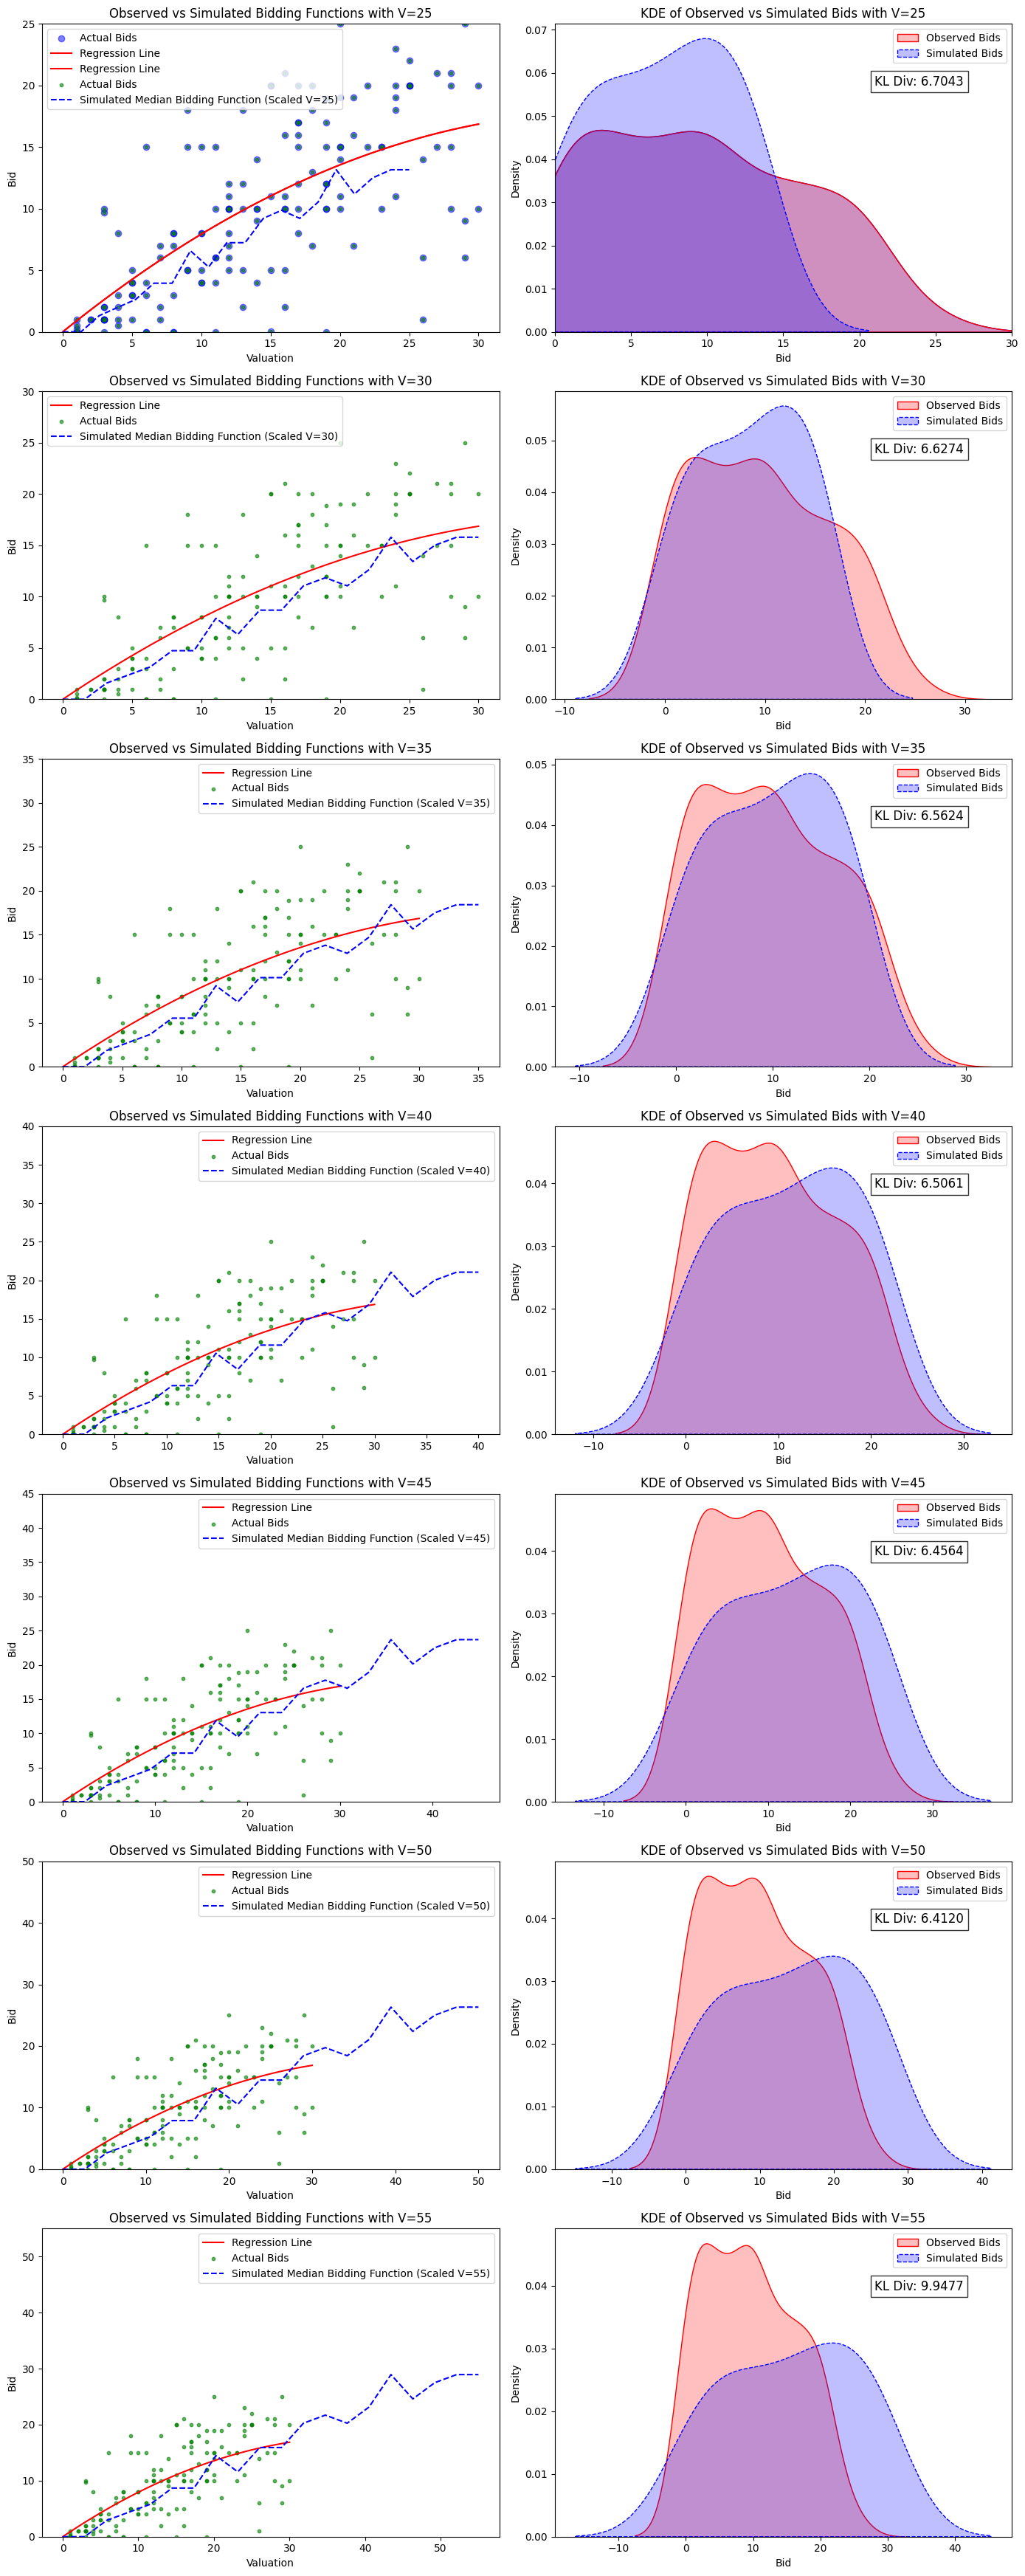

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import statsmodels.api as sm

# ========== Section 1: Data Loading and Plotting ==========

def load_and_clean_data(filepath):
    print("Loading and cleaning data...")
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_fp'] <= 30) & 
                        (data['bid_fp'] >= 0) &
                        (data['value_fp'] <= 30) &
                        (data['value_fp'] >= 0)]
    print(f"Loaded and cleaned {len(cleaned_data)} rows.")
    return cleaned_data

def plot_actual_bids(filepath, axes):
    data = load_and_clean_data(filepath)
    
    data['valuation_squared'] = data['value_fp'] ** 2
    X = data[['value_fp', 'valuation_squared']]  
    y = data['bid_fp']  
    model = sm.OLS(y, X).fit()
    
    valuation_grid = np.linspace(0, 30, 100)
    predicted_bids = model.predict(np.column_stack((valuation_grid, valuation_grid ** 2)))
    
    axes[0].scatter(data['value_fp'], data['bid_fp'], color='blue', alpha=0.5, label='Actual Bids')
    axes[0].plot(valuation_grid, predicted_bids, color='red', label='Regression Line')
    axes[0].set_xlabel('Valuation')
    axes[0].set_ylabel('Bid')
    axes[0].set_title('Actual Bids vs Valuation')
    axes[0].legend()
    axes[0].set_ylim(0, 30)
    
    sns.kdeplot(data['bid_fp'], ax=axes[1], fill=True, color='blue')
    axes[1].set_xlabel('Bid')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Distribution of Bids')
    axes[1].set_xlim(0, 30)
    
    return model, valuation_grid, predicted_bids

# ========== Section 2: Q-Learning Agents and Auction Setup ==========

class QLearningAgent:
    def __init__(self, granularity=20, epsilon=0.1, alpha=0.1):
        self.granularity = granularity
        self.actions = np.linspace(0, 1, self.granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.q_values = np.zeros((self.granularity, len(self.actions)))
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule

    def run_auction(self):
        for agent in self.agents: agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
                agent.feedback(payoff, bids[idx])
            else:
                agent.feedback(0, bids[idx])

def first_price_rule(bids):
    winner_index = np.argmax(bids)
    return winner_index, bids[winner_index]

def kl_divergence(p, q, bins=30):
    p_hist, _ = np.histogram(p, bins=bins, density=True)
    q_hist, _ = np.histogram(q, bins=bins, density=True)
    return entropy(p_hist + 1e-8, q_hist + 1e-8)

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    
    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
    
    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    
    return percentiles

def run_single_simulation(agents, game, num_rounds=20000):
    for _ in range(num_rounds): game.run_auction()

def get_true_bids(filepath):
    data = load_and_clean_data(filepath)
    return data['value_fp'], data['bid_fp']

# ========== Section 3: Plotting Simulated Results for Multiple V Values ==========

def plot_simulation_for_v_values(filepath, percentiles, v_values, axes, valuation_grid, predicted_bids, model):
    true_valuations, true_bids = get_true_bids(filepath)
    for i, V in enumerate(v_values):
        # Left column: Plot observed vs simulated bidding functions
        valuations_scaled = np.linspace(0, V, len(percentiles[0]["median"]))
        simulated_bids_scaled = V * percentiles[0]["median"]

        # Plot observed vs simulated bidding functions with actual data points for each V
        axes[i, 0].plot(valuation_grid, predicted_bids, label='Regression Line', color='red')
        axes[i, 0].scatter(true_valuations, true_bids, label='Actual Bids', color='green', s=10, alpha=0.6)
        axes[i, 0].plot(valuations_scaled, simulated_bids_scaled, label=f'Simulated Median Bidding Function (Scaled V={V})', color='blue', linestyle='--')
        axes[i, 0].set_xlabel('Valuation')
        axes[i, 0].set_ylabel('Bid')
        axes[i, 0].set_title(f'Observed vs Simulated Bidding Functions with V={V}')
        axes[i, 0].legend()
        axes[i, 0].set_ylim(0, V)
        
        # Right column: KDE of observed and simulated bids with KL divergence
        sns.kdeplot(true_bids, label='Observed Bids', color='red', fill=True, ax=axes[i, 1])
        sns.kdeplot(simulated_bids_scaled, label='Simulated Bids', color='blue', linestyle='--', fill=True, ax=axes[i, 1])
        axes[i, 1].set_xlabel('Bid')
        axes[i, 1].set_ylabel('Density')
        axes[i, 1].set_title(f'KDE of Observed vs Simulated Bids with V={V}')

        # Calculate and display KL divergence
        kl_div = kl_divergence(true_bids, simulated_bids_scaled)
        axes[i, 1].text(0.7, 0.8, f'KL Div: {kl_div:.4f}', transform=axes[i, 1].transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
        axes[i, 1].legend()

# ========== Example Usage ==========
v_values = [25, 30, 35, 40, 45, 50, 55]  # Testing for multiple valuation ranges
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
fig, axes = plt.subplots(len(v_values), 2, figsize=(14, len(v_values) * 5))
model, valuation_grid, predicted_bids = plot_actual_bids(filepath, axes[0])
num_agents = 2
agents = [QLearningAgent() for _ in range(num_agents)]
auction = SingleSidedAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=20000)
plot_simulation_for_v_values(filepath, percentiles, v_values, axes, valuation_grid, predicted_bids, model)
plt.tight_layout()
plt.show()

Loading and cleaning data...
Loaded and cleaned 145 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Loading and cleaning data...
Loaded and cleaned 145 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

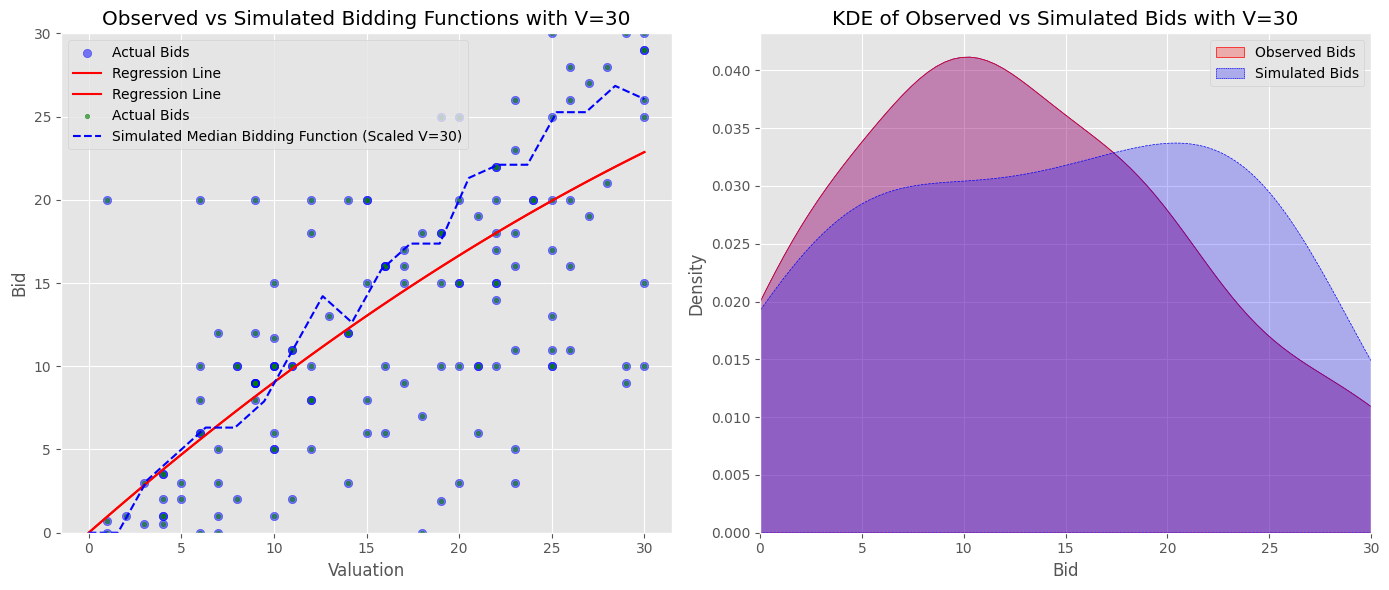

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import statsmodels.api as sm

# ========== Section 1: Data Loading and Plotting for Second Price Auction ==========

def load_and_clean_data(filepath):
    print("Loading and cleaning data...")
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_sp'] <= 100) & 
                        (data['bid_sp'] >= 0) &
                        (data['value_sp'] <= 30) &
                        (data['value_sp'] >= 0)]
    print(f"Loaded and cleaned {len(cleaned_data)} rows.")
    return cleaned_data

def plot_actual_bids(filepath, axes):
    data = load_and_clean_data(filepath)
    
    # Regression: bid on valuation and valuation^2 without a constant
    data['valuation_squared'] = data['value_sp'] ** 2
    X = data[['value_sp', 'valuation_squared']]  
    y = data['bid_sp']  
    model = sm.OLS(y, X).fit()
    
    valuation_grid = np.linspace(0, 30, 100)
    predicted_bids = model.predict(np.column_stack((valuation_grid, valuation_grid ** 2)))
    
    axes[0].scatter(data['value_sp'], data['bid_sp'], color='blue', alpha=0.5, label='Actual Bids')
    axes[0].plot(valuation_grid, predicted_bids, color='red', label='Regression Line')
    axes[0].set_xlabel('Valuation')
    axes[0].set_ylabel('Bid')
    axes[0].set_title('Actual Second Price Bids vs Valuation')
    axes[0].legend()
    axes[0].set_ylim(0, 30)
    
    sns.kdeplot(data['bid_sp'], ax=axes[1], fill=True, color='blue')
    axes[1].set_xlabel('Bid')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Distribution of Second Price Bids')
    axes[1].set_xlim(0, 30)
    
    return model, valuation_grid, predicted_bids

# ========== Section 2: Q-Learning Agents and Second Price Auction Setup ==========

class QLearningAgent:
    def __init__(self, granularity=20, epsilon=0.1, alpha=0.1):
        self.granularity = granularity
        self.actions = np.linspace(0, 1, self.granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.q_values = np.zeros((self.granularity, len(self.actions)))
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule

    def run_auction(self):
        for agent in self.agents: agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
                agent.feedback(payoff, bids[idx])
            else:
                agent.feedback(0, bids[idx])

def second_price_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    second_highest_bid = np.partition(bids, -2)[-2]  # Second-highest bid for payment
    return winner, second_highest_bid

# ========== Section 3: Monte Carlo Simulation ==========

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    
    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
    
    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    
    return percentiles

def run_single_simulation(agents, game, num_rounds=20000):
    for _ in range(num_rounds): game.run_auction()

def get_true_bids(filepath):
    data = load_and_clean_data(filepath)
    return data['value_sp'], data['bid_sp']

# ========== Section 4: Plotting Simulated vs Actual Bids for Second Price Auction ==========

def plot_simulation_results(filepath, percentiles, V, axes, valuation_grid, predicted_bids, model):
    true_valuations, true_bids = get_true_bids(filepath)
    
    # Scale simulated percentiles to the range [0, V]
    valuations_scaled = np.linspace(0, V, len(percentiles[0]["median"]))
    simulated_bids_scaled = V * percentiles[0]["median"]

    # Left: Plot observed vs simulated bidding functions
    axes[0].plot(valuation_grid, predicted_bids, label='Regression Line', color='red')
    axes[0].scatter(true_valuations, true_bids, label='Actual Bids', color='green', s=10, alpha=0.6)
    axes[0].plot(valuations_scaled, simulated_bids_scaled, label=f'Simulated Median Bidding Function (Scaled V={V})', color='blue', linestyle='--')
    axes[0].set_xlabel('Valuation')
    axes[0].set_ylabel('Bid')
    axes[0].set_title(f'Observed vs Simulated Bidding Functions with V={V}')
    axes[0].legend()
    axes[0].set_ylim(0, V)
    
    # Right: KDE of observed and simulated bids
    sns.kdeplot(true_bids, label='Observed Bids', color='red', fill=True, ax=axes[1])
    sns.kdeplot(simulated_bids_scaled, label='Simulated Bids', color='blue', linestyle='--', fill=True, ax=axes[1])
    axes[1].set_xlabel('Bid')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'KDE of Observed vs Simulated Bids with V={V}')
    axes[1].legend()

# ========== Example Usage ==========

V = 30  # Use a single V value
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load actual bids and set up plot
model, valuation_grid, predicted_bids = plot_actual_bids(filepath, axes)

# Run Monte Carlo simulations for second price auction
num_agents = 2
agents = [QLearningAgent() for _ in range(num_agents)]
auction = SingleSidedAuction(agents, payment_rule=second_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=20000)

# Plot results: simulated vs actual bids
plot_simulation_results(filepath, percentiles, V, axes, valuation_grid, predicted_bids, model)
plt.tight_layout()
plt.show()

Loading and cleaning data...
Loaded and cleaned 135 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Loading and cleaning data...
Loaded and cleaned 135 rows.


/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/econ_share/home/pp712/myenv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Co

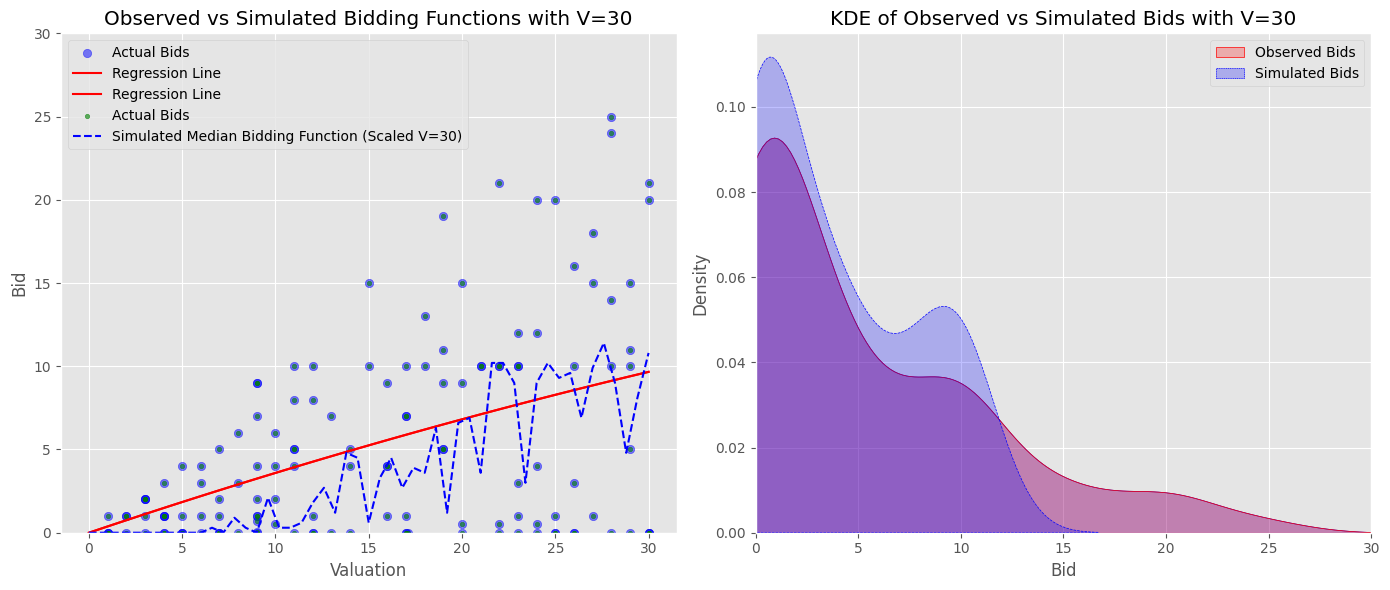

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import statsmodels.api as sm

# ========== Section 1: Data Loading and Plotting for All-Pay Auction ==========

def load_and_clean_data(filepath):
    print("Loading and cleaning data...")
    data = pd.read_csv(filepath)
    cleaned_data = data[(data['matched_info'] == 'yes') & 
                        (data['bid_ap'] <= data['value_ap']) & 
                        (data['bid_ap'] >= 0) &
                        (data['value_ap'] <= 30) &
                        (data['value_ap'] >= 0)]
    print(f"Loaded and cleaned {len(cleaned_data)} rows.")
    return cleaned_data

def plot_actual_bids(filepath, axes):
    data = load_and_clean_data(filepath)
    
    # Regression: bid on valuation and valuation^2 without a constant
    data['valuation_squared'] = data['value_ap'] ** 2
    X = data[['value_ap', 'valuation_squared']]  
    y = data['bid_ap']  
    model = sm.OLS(y, X).fit()
    
    valuation_grid = np.linspace(0, 30, 100)
    predicted_bids = model.predict(np.column_stack((valuation_grid, valuation_grid ** 2)))
    
    axes[0].scatter(data['value_ap'], data['bid_ap'], color='blue', alpha=0.5, label='Actual Bids')
    axes[0].plot(valuation_grid, predicted_bids, color='red', label='Regression Line')
    axes[0].set_xlabel('Valuation')
    axes[0].set_ylabel('Bid')
    axes[0].set_title('Actual All-Pay Bids vs Valuation')
    axes[0].legend()
    axes[0].set_ylim(0, 30)
    
    sns.kdeplot(data['bid_ap'], ax=axes[1], fill=True, color='blue')
    axes[1].set_xlabel('Bid')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Distribution of All-Pay Bids')
    axes[1].set_xlim(0, 30)
    
    return model, valuation_grid, predicted_bids

# ========== Section 2: All-Pay Auction Setup ==========

class QLearningAgent:
    def __init__(self, granularity=51, epsilon=0.99, alpha=0.1, epsilon_decay=0.99999):
        self.granularity = granularity
        self.actions = np.linspace(0, 1, granularity)
        self.epsilon = epsilon
        self.alpha = alpha
        self.epsilon_min = 0.1  # Epsilon minimum value
        self.epsilon_decay = epsilon_decay
        self.q_values = np.zeros((self.granularity, len(self.actions)))
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(0, 1, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = np.random.uniform(0, 1)
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]

    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])

    def feedback(self, reward, action):
        self.update_q_values(action, reward)
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)  # Apply epsilon decay

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule

    def run_auction(self):
        for agent in self.agents: agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                reward = agent.valuation - bids[idx]
            else:
                reward = -bids[idx]  # Losers lose their bid amount
            agent.feedback(reward, bids[idx])

def all_pay_rule(bids):
    max_bid = np.max(bids)
    winner_candidates = np.where(bids == max_bid)[0]
    winner = np.random.choice(winner_candidates) if len(winner_candidates) > 1 else winner_candidates[0]
    total_payment = np.sum(bids)  # All bidders pay their bids
    return winner, total_payment

# ========== Section 3: Monte Carlo Simulation for All-Pay Auction ==========

def run_monte_carlo_simulation(agents, auction, num_simulations=30, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    
    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
    
    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    
    return percentiles

def run_single_simulation(agents, game, num_rounds=20000):
    for _ in range(num_rounds): game.run_auction()

def get_true_bids(filepath):
    data = load_and_clean_data(filepath)
    return data['value_ap'], data['bid_ap']

# ========== Section 4: Plotting Simulated vs Actual Bids for All-Pay Auction ==========

def plot_simulation_results(filepath, percentiles, V, axes, valuation_grid, predicted_bids, model):
    true_valuations, true_bids = get_true_bids(filepath)
    
    # Scale simulated percentiles to the range [0, V]
    valuations_scaled = np.linspace(0, V, len(percentiles[0]["median"]))
    simulated_bids_scaled = V * percentiles[0]["median"]

    # Left: Plot observed vs simulated bidding functions
    axes[0].plot(valuation_grid, predicted_bids, label='Regression Line', color='red')
    axes[0].scatter(true_valuations, true_bids, label='Actual Bids', color='green', s=10, alpha=0.6)
    axes[0].plot(valuations_scaled, simulated_bids_scaled, label=f'Simulated Median Bidding Function (Scaled V={V})', color='blue', linestyle='--')
    axes[0].set_xlabel('Valuation')
    axes[0].set_ylabel('Bid')
    axes[0].set_title(f'Observed vs Simulated Bidding Functions with V={V}')
    axes[0].legend()
    axes[0].set_ylim(0, V)
    
    # Right: KDE of observed and simulated bids
    sns.kdeplot(true_bids, label='Observed Bids', color='red', fill=True, ax=axes[1])
    sns.kdeplot(simulated_bids_scaled, label='Simulated Bids', color='blue', linestyle='--', fill=True, ax=axes[1])
    axes[1].set_xlabel('Bid')
    axes[1].set_ylabel('Density')
    axes[1].set_title(f'KDE of Observed vs Simulated Bids with V={V}')
    axes[1].legend()

# ========== Example Usage ==========

V = 30  # Use a single V value
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load actual bids and set up plot
model, valuation_grid, predicted_bids = plot_actual_bids(filepath, axes)

# Run Monte Carlo simulations for all-pay auction
num_agents = 2
agents = [QLearningAgent() for _ in range(num_agents)]
auction = SingleSidedAuction(agents, payment_rule=all_pay_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=2, num_rounds=100000)

# Plot results: simulated vs actual bids
plot_simulation_results(filepath, percentiles, V, axes, valuation_grid, predicted_bids, model)

plt.tight_layout()
plt.show()